# 0. Connect Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import Libraries

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

In [3]:
import os

def find_project_dir(folder_name, start_path="/content/drive/MyDrive"):
    """
    Durchsucht Google Drive nach einem bestimmten Ordnernamen
    und gibt den absoluten Pfad zurück.
    """
    if not os.path.exists(start_path):
        print("Fehler: Google Drive ist nicht gemountet! Bitte zuerst drive.mount('/content/drive') ausführen.")
        return None

    print(f"Durchsuche Drive nach '{folder_name}'...")
    for root, dirs, files in os.walk(start_path):
        if folder_name in dirs:
            found_path = os.path.join(root, folder_name)
            print(f"🎉 Ordner gefunden! Pfad lautet:\n{found_path}")
            return found_path

    print(f"❌ Ordner '{folder_name}' konnte in {start_path} nicht gefunden werden.")
    return None

# --- ANWENDUNG ---
# Du musst hier nur den exakten Namen des Zielordners angeben
target_folder = "w3_group-6-cnn-image-classification"
project_dir = find_project_dir(target_folder)

# Wenn der Ordner gefunden wurde, wechsle direkt dorthin
if project_dir:
    os.chdir(project_dir)

Durchsuche Drive nach 'w3_group-6-cnn-image-classification'...
🎉 Ordner gefunden! Pfad lautet:
/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification


# 2. Load Split Dataset

In [4]:
import sys

project_dir = "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification"
sys.path.append(project_dir)

from utils import load_animals10_datasets

train_dataset, val_dataset, test_dataset, class_names = load_animals10_datasets()

Using Colab cache for faster access to the 'animals10' dataset.


### Check Data

In [5]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

print(class_names)

(32, 128, 128, 3)
(32, 10)
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# 3. Define Model

In [9]:
from keras.backend import clear_session
clear_session()

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

num_classes = 10
input_shape= (128, 128, 3)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
        layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,546 (1.62 MB)

 Trainable params: 425,546 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and Train Model

In [11]:
import time
from keras.optimizers import Adam

epochs = 30
my_opt = Adam(learning_rate=0.0001)

model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt,
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)
# Track train time: end timing
end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.2015 - loss: 2.1840 - val_accuracy: 0.2406 - val_loss: 2.1210
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.2449 - loss: 2.0882 - val_accuracy: 0.2937 - val_loss: 2.0123
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.2843 - loss: 2.0009 - val_accuracy: 0.3453 - val_loss: 1.8984
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - accuracy: 0.3301 - loss: 1.9033 - val_accuracy: 0.3938 - val_loss: 1.8013
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.3714 - loss: 1.8237 - val_accuracy: 0.4244 - val_loss: 1.7123
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 84s 84ms/step - accuracy: 0.3959 - loss: 1.7452 - val_accuracy: 0.4484 - val_loss: 1.6407
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 54s 82ms/step - accuracy: 0.4232 - loss: 1.6802 - val_accuracy: 0.4744 - val_loss: 1.5674
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - accuracy: 0.4412 - loss: 1.6172 -

# 5. Evaluate Model

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy: {accuracy}")
print(f"Test precision: {precision}")
print(f"Test recall: {recall}")
print(f"Confusion Matrix: \n {cm}")

Test accuracy: 0.606951871657754
Test precision: 0.5623203437655784
Test recall: 0.5356414582186318
Confusion Matrix: 
 [[350  44   9   5  24  11   8  13  16   7]
 [ 38 158  25   2   7   1   8  19   3   1]
 [  5  21  84   0   0   1   3  24   3   4]
 [  2   3   1 155   6   1   0   2  39   2]
 [ 13  10   8   8 249   0   0   7   7   8]
 [ 78   1   6   4   5  22   0   2  31  18]
 [ 24  80  24   0   7   0  27  20   3   1]
 [ 14  13  25   1   8   0  16  86  15   4]
 [ 23   6   4  20  10   7   0   6 392  14]
 [ 48   1   5   4  11   6   0  12  33  66]]


# 6.Plot Loss and Accuracy

In [13]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

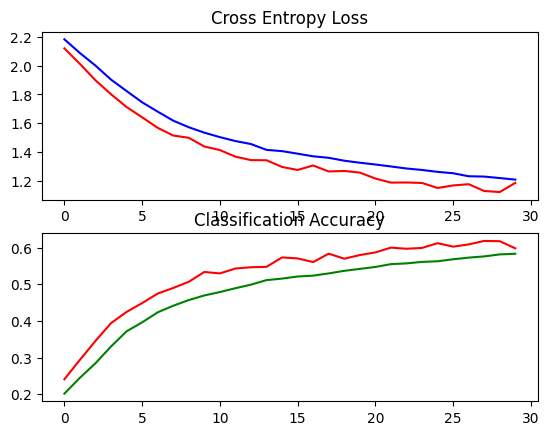

In [14]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='red', label='validation')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.plot(history.history['val_accuracy'], color='red', label='validation')
plt.show()

# 6.2 Plot Confusion Matrix

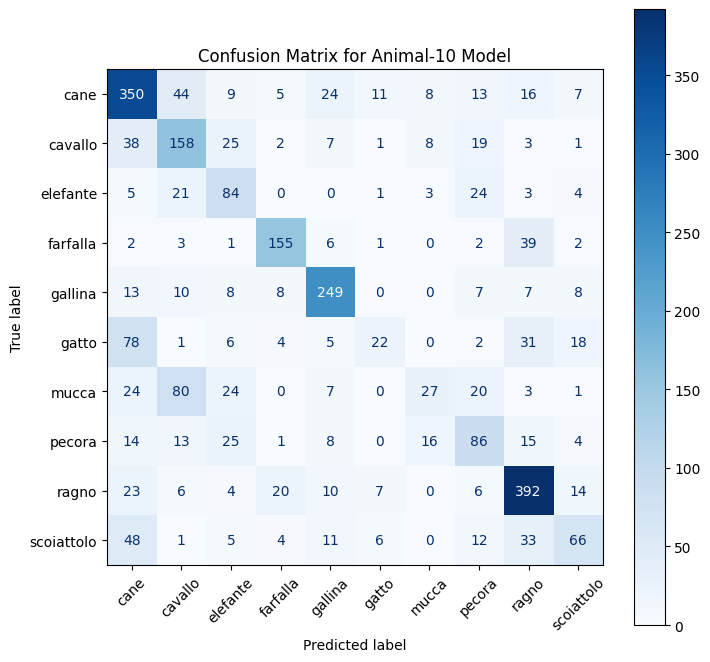

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix for Animal-10 Model")
plt.show()

# 7. Save Model

In [16]:
model.save("/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_5_global_avg_pool_wider.keras")

print("Model Saved")

Model Saved


In [17]:
# how to import model when needed

'''
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_5_global_avg_pool_wider.keras"
)
'''

'\nimport tensorflow as tf\n\nmodel = tf.keras.models.load_model(\n    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_5_global_avg_pool_wider.keras"\n)\n'